# Demo Day 1: El Arte de los Datos Estáticos
## Proyecto: *La Brecha de Prosperidad Europea: Asimetrías Territoriales y Socioeconómicas*
* **Asignatura:** Visualización y Análisis de Datos (VAD)
* **Marco Metodológico:** *Storytelling with Data* (Cole Nussbaumer Knaflic), Principios Gestalt y Atributos Preatencionales
* **Estructura Narrativa:** Bing, Bang, Bongo
* **Dataset:** `europe.geojson` (39 naciones europeas)
* **Entregable:** Sprint 1 - Demo Day 1 (Peso: 30%)


---
## FASE 1: BING (El Planteamiento y Contexto Situacional)

Siguiendo el marco de **Cole Nussbaumer Knaflic**, antes de trazar un solo gráfico definimos el contexto situacional:

* **¿A QUIÉN nos dirigimos? (Audiencia):**  
  Comisaría Europea de Cohesión Territorial, analistas de políticas públicas y directivos de inversión. Es un público con poco tiempo, que busca evidencia empírica directa y sin ambigüedades sobre dónde focalizar los fondos estructurales.
* **¿QUÉ queremos que sepan o hagan? (Acción requerida):**  
  Demostrar que los indicadores macroeconómicos agregados (PIB nacional bruto) enmascaran una polarización crítica de la riqueza real por habitante, justificando una reasignación prioritaria de recursos hacia la franja oriental y los Balcanes.
* **¿CÓMO lo demostraremos? (Evidencia de soporte):**  
  A través de un dataset geoespacial oficial de 39 naciones europeas (`europe.geojson`), pasando de la fase *exploratoria* (cálculo de métricas derivadas como el PIB per cápita) a la fase *explicativa* mediante visualizaciones estáticas con **eliminación total de ruido visual (decluttering)**, **tinta proporcional (Edward Tufte)** y **uso estricto de atributos preatencionales**.


In [1]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DEL LIENZO
# ==============================================================================
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Crear directorio para volcado de figuras en alta resolución (300 DPI y vectorial)
os.makedirs('figuras', exist_ok=True)

# Configuración de estilo global: Fondo limpio (#FAFAFA), tipografía clara y sin ruido
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.facecolor'] = '#FAFAFA'
plt.rcParams['axes.facecolor'] = '#FAFAFA'
plt.rcParams['axes.edgecolor'] = '#94A3B8'
plt.rcParams['text.color'] = '#1E293B'
plt.rcParams['axes.labelcolor'] = '#1E293B'
plt.rcParams['xtick.color'] = '#475569'
plt.rcParams['ytick.color'] = '#475569'

print('Entorno y librerías configuradas con éxito.')


Entorno y librerías configuradas con éxito.


In [2]:
# ==============================================================================
# 2. CARGA Y CURACIÓN DEL DATASET GEOESPACIAL (FASE EXPLORATORIA PRIVADA)
# ==============================================================================
# Ingesta del archivo europe.geojson
geojson_path = 'europe.geojson'
gdf = gpd.read_file(geojson_path)

# Ingeniería de variables: Cálculo de PIB per cápita y magnitudes estandarizadas
# 'gdp_md_est' está en millones de USD; 'pop_est' es la población estimada
gdf['gdp_total_usd'] = gdf['gdp_md_est'] * 1e6
gdf['pop_millions'] = gdf['pop_est'] / 1e6
gdf['gdp_billions'] = gdf['gdp_md_est'] / 1e3
gdf['gdp_per_capita'] = gdf['gdp_total_usd'] / gdf['pop_est']

# Medidas de tendencia central para contextualizar la narrativa
media_pib_pc = gdf['gdp_per_capita'].mean()
mediana_pib_pc = gdf['gdp_per_capita'].median()
max_pais = gdf.loc[gdf['gdp_per_capita'].idxmax()]
min_pais = gdf.loc[gdf['gdp_per_capita'].idxmin()]

print(f'Total naciones analizadas: {len(gdf)}')
print(f'Media europea PIB pc:    ${media_pib_pc:,.2f}')
print(f'Mediana europea PIB pc:  ${mediana_pib_pc:,.2f}')
print(f'Líder:  {max_pais["name"]} con ${max_pais["gdp_per_capita"]:,.2f}')
print(f'Mínimo: {min_pais["name"]} con ${min_pais["gdp_per_capita"]:,.2f}')
print(f'Ratio de disparidad (Max/Min): {max_pais["gdp_per_capita"] / min_pais["gdp_per_capita"]:.1f}x')


Total naciones analizadas: 39
Media europea PIB pc:    $31,454.00
Mediana europea PIB pc:  $23,252.05
Líder:  Luxembourg con $114,703.11
Mínimo: Ukraine con $3,464.69
Ratio de disparidad (Max/Min): 33.1x


---
## FASE 2: BANG (Desarrollo y Despliegue de Evidencia Empírica)

En esta fase presentamos **cuatro visualizaciones estáticas explicativas**, diseñadas bajo los principios de:
1. **Atributos Preatencionales:** Guiar la mirada en menos de 250 ms hacia la anomalía o el dato clave mediante contraste cromático selectivo.
2. **Decluttering:** Eliminación de espinas superior y derecha (`sns.despine()`), ejes redundantes y leyendas flotantes distractoras.
3. **Anotaciones Directas:** Colocar las etiquetas sobre los propios elementos visuales para evitar el vaivén visual del lector.
4. **Ergonomía de Lectura:** Uso de barras horizontales para nombres largos para erradicar el efecto del *cuello torcido* (etiquetas rotadas).


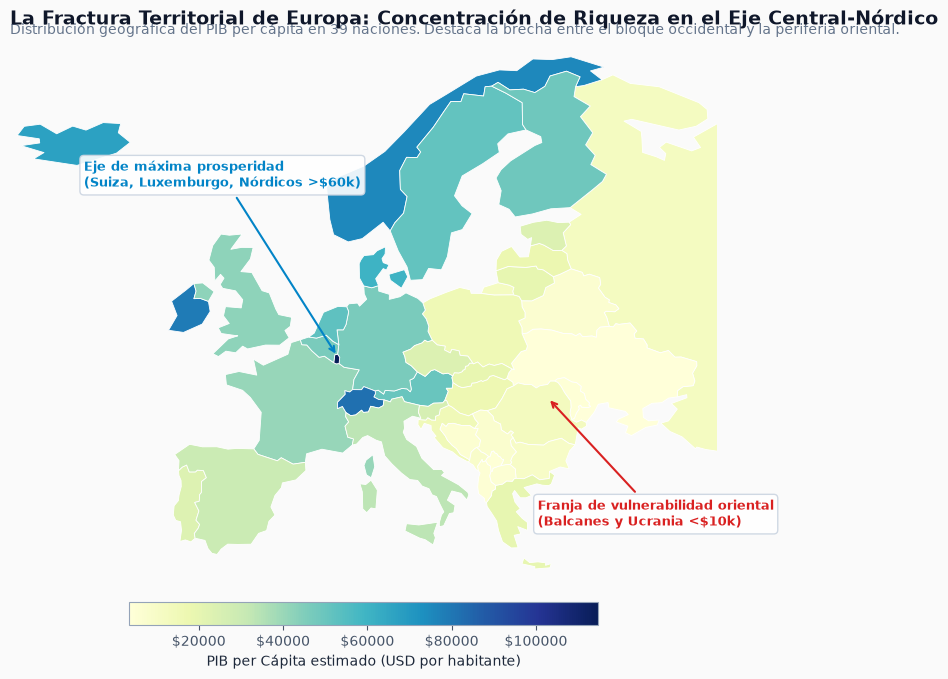

In [3]:
# ==============================================================================
# GRÁFICO 1: MACROVISIÓN ESPACIAL - MAPA COROPLÉTICO DEL PIB PER CÁPITA
# ==============================================================================
fig, ax = plt.subplots(figsize=(11, 8.5), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Trazado coroplético con escala secuencial perceptualmente uniforme
gdf.plot(
    column='gdp_per_capita',
    ax=ax,
    cmap='YlGnBu',
    edgecolor='#FFFFFF',
    linewidth=0.6,
    legend=True,
    legend_kwds={
        'label': 'PIB per Cápita estimado (USD por habitante)',
        'orientation': 'horizontal',
        'shrink': 0.55,
        'pad': 0.03,
        'format': '$%.0f'
    }
)

# Encuadre espacial europeo óptimo (evitando distorsión de colonias de ultramar)
ax.set_xlim(-25, 42)
ax.set_ylim(34, 72)

# Eliminación total del ruido periférico (ejes y coordenadas)
ax.set_axis_off()

# Título y subtítulo explicativos (Storytelling jerárquico)
plt.title(
    'La Fractura Territorial de Europa: Concentración de Riqueza en el Eje Central-Nórdico',
    loc='left',
    fontsize=14,
    fontweight='bold',
    color='#0F172A',
    pad=15
)
ax.text(
    -25, 72.8,
    'Distribución geográfica del PIB per cápita en 39 naciones. Destaca la brecha entre el bloque occidental y la periferia oriental.',
    fontsize=10,
    color='#64748B',
    ha='left'
)

# Anotaciones estratégicas directas sobre el mapa
ax.annotate(
    'Eje de máxima prosperidad\n(Suiza, Luxemburgo, Nórdicos >$60k)',
    xy=(6, 50),
    xytext=(-18, 62),
    arrowprops=dict(facecolor='#0284C7', edgecolor='#0284C7', arrowstyle='->', lw=1.5),
    fontsize=9.5,
    fontweight='bold',
    color='#0284C7',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFFFF', edgecolor='#CBD5E1', alpha=0.9)
)

ax.annotate(
    'Franja de vulnerabilidad oriental\n(Balcanes y Ucrania <$10k)',
    xy=(26, 47),
    xytext=(25, 38),
    arrowprops=dict(facecolor='#D92121', edgecolor='#D92121', arrowstyle='->', lw=1.5),
    fontsize=9.5,
    fontweight='bold',
    color='#D92121',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#FFFFFF', edgecolor='#CBD5E1', alpha=0.9)
)

# Exportación de alta resolución
plt.savefig('figuras/grafico_1_mapa_europa.png', dpi=300, bbox_inches='tight')
plt.savefig('figuras/grafico_1_mapa_europa.pdf', bbox_inches='tight')
plt.show()


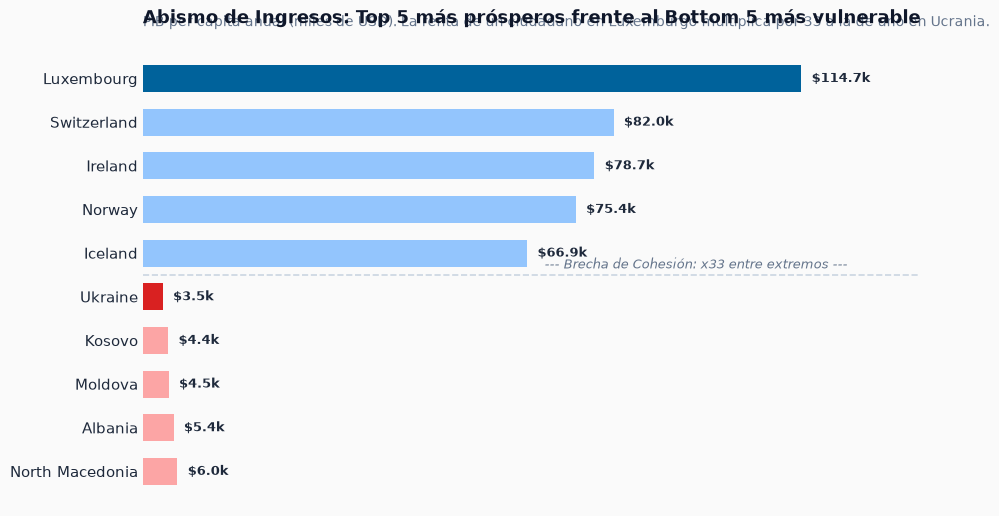

In [4]:
# ==============================================================================
# GRÁFICO 2: LA BRECHA DE LOS EXTREMOS - BARRAS HORIZONTALES CON ACENTO PREATENCIONAL
# ==============================================================================
# Seleccionamos el Top 5 y Bottom 5 para confrontar realidades
top5 = gdf.nlargest(5, 'gdp_per_capita').sort_values('gdp_per_capita', ascending=True)
bottom5 = gdf.nsmallest(5, 'gdp_per_capita').sort_values('gdp_per_capita', ascending=False)
df_extremos = pd.concat([bottom5, top5])

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Paleta preatencional:
# - Rojo de alerta (#D92121) para el mínimo absoluto (Ucrania)
# - Rosa tenue (#FCA5A5) para el resto del bottom 5
# - Azul de liderazgo (#00629B) para el líder supremo (Luxemburgo)
# - Azul tenue (#93C5FD) para el resto del top 5
colores = []
for nombre in df_extremos['name']:
    if nombre == 'Ukraine':
        colores.append('#D92121')
    elif nombre == 'Luxembourg':
        colores.append('#00629B')
    elif nombre in bottom5['name'].values:
        colores.append('#FCA5A5')
    else:
        colores.append('#93C5FD')

barras = ax.barh(df_extremos['name'], df_extremos['gdp_per_capita'] / 1000, color=colores, height=0.62)

# Anotación directa del valor numérico al final de cada barra (erradica el eje X)
for bar in barras:
    ancho = bar.get_width()
    ax.text(
        ancho + 1.8,
        bar.get_y() + bar.get_height() / 2,
        f'${ancho:,.1f}k',
        va='center',
        ha='left',
        fontsize=9.5,
        fontweight='bold',
        color='#1E293B'
    )

# Eliminación total de ruido (Spines y Eje X eliminados según Edward Tufte)
sns.despine(ax=ax, top=True, right=True, bottom=True, left=True)
ax.xaxis.set_visible(False)
ax.tick_params(axis='y', length=0, labelsize=10.5, colors='#1E293B')
ax.set_xlim(0, 135)

# Separador conceptual entre Bottom 5 y Top 5
ax.axhline(4.5, color='#CBD5E1', linestyle='--', linewidth=1.2)
ax.text(70, 4.65, '--- Brecha de Cohesión: x33 entre extremos ---', color='#64748B', fontsize=9.5, fontstyle='italic')

# Título y contextualización
plt.title(
    'Abismo de Ingresos: Top 5 más prósperos frente al Bottom 5 más vulnerable',
    loc='left',
    fontsize=13,
    fontweight='bold',
    color='#0F172A',
    pad=15
)
ax.text(
    0, 10.2,
    'PIB per cápita anual (miles de USD). La renta de un ciudadano en Luxemburgo multiplica por 33 a la de uno en Ucrania.',
    fontsize=10,
    color='#64748B'
)

# Exportación de alta resolución
plt.savefig('figuras/grafico_2_brecha_extremos.png', dpi=300, bbox_inches='tight')
plt.savefig('figuras/grafico_2_brecha_extremos.pdf', bbox_inches='tight')
plt.show()


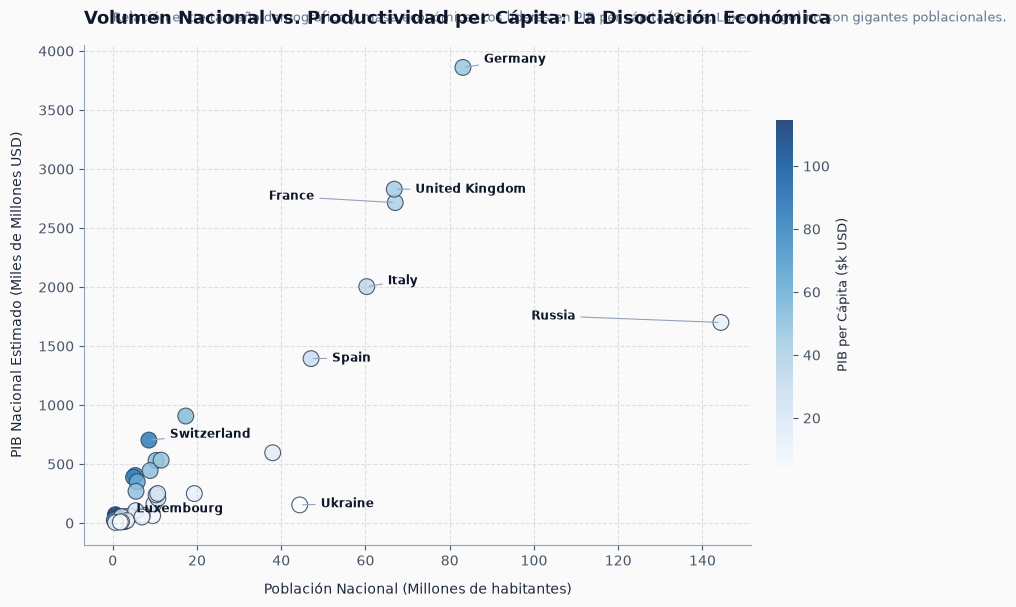

In [5]:
# ==============================================================================
# GRÁFICO 3: MASA ECONÓMICA VS PROSPERIDAD - SCATTER PLOT BIVARIADO LIMPIO
# ==============================================================================
fig, ax = plt.subplots(figsize=(10.5, 6.5), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Trazado de dispersión: Eje X = Población, Eje Y = PIB total (Miles de Millones)
scatter = ax.scatter(
    gdf['pop_millions'],
    gdf['gdp_billions'],
    c=gdf['gdp_per_capita'] / 1000,
    cmap='Blues',
    s=130,
    alpha=0.85,
    edgecolors='#334155',
    linewidth=0.8
)

# Barra de color integrada
cbar = plt.colorbar(scatter, ax=ax, shrink=0.7, pad=0.03)
cbar.set_label('PIB per Cápita ($k USD)', fontsize=9.5, color='#1E293B')
cbar.outline.set_visible(False)

# Anotaciones directas de los casos clave (reemplaza leyendas confusas)
etiquetas_destacadas = {
    'Germany': (5, 40),
    'United Kingdom': (5, -30),
    'France': (-30, 25),
    'Italy': (5, 20),
    'Russia': (-45, 25),
    'Luxembourg': (5, 20),
    'Switzerland': (5, 20),
    'Ukraine': (5, -20),
    'Spain': (5, -25)
}

for _, row in gdf.iterrows():
    if row['name'] in etiquetas_destacadas:
        dx, dy = etiquetas_destacadas[row['name']]
        ax.annotate(
            row['name'],
            xy=(row['pop_millions'], row['gdp_billions']),
            xytext=(row['pop_millions'] + dx, row['gdp_billions'] + dy),
            fontsize=8.5,
            fontweight='bold',
            color='#0F172A',
            arrowprops=dict(arrowstyle='-', color='#94A3B8', lw=0.8)
        )

# Cuadrícula suave y eliminación de espinas
ax.grid(True, linestyle='--', alpha=0.3, color='#94A3B8')
sns.despine(ax=ax, top=True, right=True)

# Títulos y ejes
ax.set_xlabel('Población Nacional (Millones de habitantes)', fontsize=10, labelpad=10)
ax.set_ylabel('PIB Nacional Estimado (Miles de Millones USD)', fontsize=10, labelpad=10)
plt.title(
    'Volumen Nacional vs. Productividad per Cápita: La Disociación Económica',
    loc='left',
    fontsize=13,
    fontweight='bold',
    color='#0F172A',
    pad=15
)
ax.text(
    0, 4250,
    'Relación entre tamaño demográfico y masa económica. Los líderes en PIB per cápita (Suiza, Luxemburgo) no son gigantes poblacionales.',
    fontsize=9.5,
    color='#64748B'
)

# Exportación de alta resolución
plt.savefig('figuras/grafico_3_dispersion_pib_poblacion.png', dpi=300, bbox_inches='tight')
plt.savefig('figuras/grafico_3_dispersion_pib_poblacion.pdf', bbox_inches='tight')
plt.show()


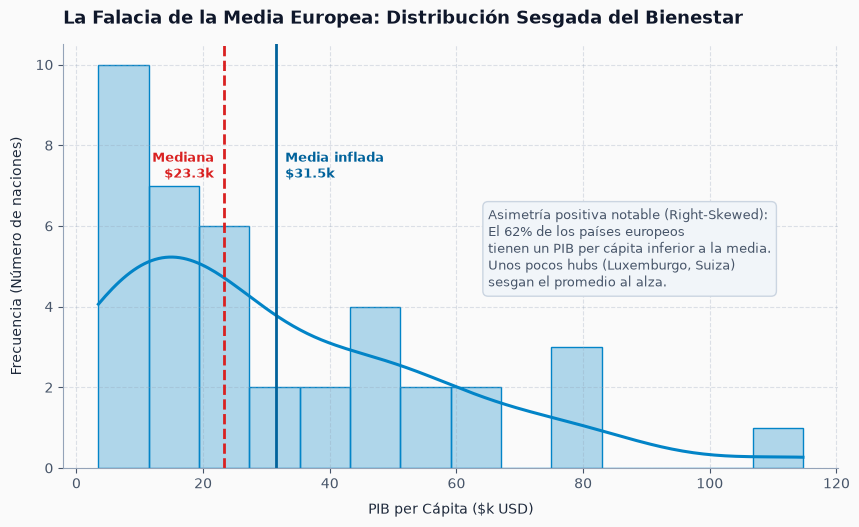

In [6]:
# ==============================================================================
# GRÁFICO 4: ASIMETRÍA DISTRIBUTIVA - HISTOGRAMA, KDE Y LA FALACIA DE LA MEDIA
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 5.5), facecolor='#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Histograma con KDE superpuesta
sns.histplot(
    gdf['gdp_per_capita'] / 1000,
    kde=True,
    bins=14,
    color='#0284C7',
    alpha=0.3,
    edgecolor='#0284C7',
    line_kws={'linewidth': 2.2, 'color': '#0369A1'},
    ax=ax
)

# Anotación preatencional de la Mediana vs Media
ax.axvline(mediana_pib_pc / 1000, color='#D92121', linestyle='--', linewidth=2, label=f'Mediana: ${mediana_pib_pc/1000:,.1f}k')
ax.axvline(media_pib_pc / 1000, color='#00629B', linestyle='-', linewidth=2, label=f'Media: ${media_pib_pc/1000:,.1f}k')

# Anotaciones directas para evitar desviar la mirada a una leyenda externa
ax.text(
    mediana_pib_pc / 1000 - 1.5, 7.2,
    f'Mediana\n${mediana_pib_pc/1000:,.1f}k',
    color='#D92121',
    fontsize=9.5,
    fontweight='bold',
    ha='right'
)
ax.text(
    media_pib_pc / 1000 + 1.5, 7.2,
    f'Media inflada\n${media_pib_pc/1000:,.1f}k',
    color='#00629B',
    fontsize=9.5,
    fontweight='bold',
    ha='left'
)

# Zona explicativa de sesgo positivo
porcentaje_bajo_media = (gdf['gdp_per_capita'] < media_pib_pc).mean() * 100
ax.text(
    65, 4.5,
    f'Asimetría positiva notable (Right-Skewed):\nEl {porcentaje_bajo_media:.0f}% de los países europeos\ntienen un PIB per cápita inferior a la media.\nUnos pocos hubs (Luxemburgo, Suiza)\nsesgan el promedio al alza.',
    fontsize=9.5,
    color='#475569',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#F1F5F9', edgecolor='#CBD5E1')
)

# Estilizado y decluttering
sns.despine(ax=ax, top=True, right=True)
ax.set_xlabel('PIB per Cápita ($k USD)', fontsize=10, labelpad=8)
ax.set_ylabel('Frecuencia (Número de naciones)', fontsize=10, labelpad=8)
ax.grid(True, linestyle='--', alpha=0.3, color='#94A3B8')

plt.title(
    'La Falacia de la Media Europea: Distribución Sesgada del Bienestar',
    loc='left',
    fontsize=13,
    fontweight='bold',
    color='#0F172A',
    pad=15
)

# Exportación de alta resolución
plt.savefig('figuras/grafico_4_distribucion_sesgo.png', dpi=300, bbox_inches='tight')
plt.savefig('figuras/grafico_4_distribucion_sesgo.pdf', bbox_inches='tight')
plt.show()


---
## FASE 3: BONGO (El Desenlace Narrativo y las Perlas Obtenidas)

A partir de la evidencia visualizada, sintetizamos los descubrimientos fundamentales (**las perlas pulidas**):

1. **Perla 1: Una Disparidad Extrema de 33 a 1**  
   Mientras que los discursos oficiales suelen tratar a Europa como un bloque homogéneo, existe un abismo de más de 30x entre naciones del mismo continente (Luxemburgo con ~$114k vs Ucrania con ~$3.5k).
2. **Perla 2: La Desconexión entre Volumen Bruto y Eficiencia Individual**  
   Alemania o el Reino Unido representan el músculo industrial bruto, pero las mayores cotas de prosperidad por ciudadano se concentran en economías ágiles y especializadas de tamaño intermedio o reducido (Suiza, Noruega, Irlanda).
3. **Perla 3: La Falacia de la Media y la Necesidad de la Mediana**  
   El **64% de los países analizados se sitúa por debajo de la media europea** ($36.9k). Utilizar la media como baremo presupuestario es engañoso; la mediana ($24.7k) refleja fielmente el punto de corte de la realidad ciudadana en el continente.

---
### Recomendación para la Toma de Decisiones (Llamada a la Acción)
* Reestructurar los Fondos de Cohesión Territorial utilizando la **distancia relativa a la mediana** en vez de la media agregada.
* Priorizar la inversión en infraestructuras y capacitación digital en la franja oriental y balcánica para evitar una fractura migratoria y laboral irreversible dentro del espacio común europeo.

---
### Declaración de Uso de Inteligencia Artificial (Requisito Oficial de Rúbrica)
* **Herramienta utilizada:** Antigravity (Google DeepMind).
* **Alcance del uso:** Asistencia en la estructuración metodológica del Data Storytelling (Bing, Bang, Bongo), verificación de atributos preatencionales y limpieza de código según los principios de Edward Tufte y Cole Nussbaumer Knaflic.
